# Trabalho 1 — Visualizacao de Features em CNN

Neste trabalho, voce ira investigar o que uma rede convolucional aprende, usando tecnicas de visualizacao de features inspiradas no artigo da Distill: **Feature Visualization** (Olah et al., 2017).

Guia de referencia: https://distill.pub/2017/feature-visualization/

**Objetivos.**
- visualizar filtros e mapas de ativacao em diferentes camadas;
- otimizar imagens de entrada para maximizar ativacoes internas;
- comparar objetivos de otimizacao (canal, neuronio e classe);
- analisar o efeito de regularizacao na qualidade das visualizacoes;
- discutir limites e riscos de interpretacao dessas tecnicas.

**Entregaveis.**
1. Este notebook preenchido e executado.
2. Figuras geradas para cada experimento principal.
3. Respostas curtas e objetivas nas celulas de texto.
4. Conclusao final sobre utilidade e limitacoes da visualizacao de features.

**Regras gerais.**
- Use **PyTorch**.
- Registre os principais hiperparametros de cada experimento.
- Quando comparar metodos, use evidencias (figuras e metricas).
- Nao apague as celulas de enunciado.
- Justifique suas escolhas de regularizacao.

## Parte 0 — Setup e reprodutibilidade

**Tarefa 0.1**  
Fixe seeds aleatorias e configure o dispositivo (cpu ou cuda).

**Tarefa 0.2**  
Imprima as versoes de torch e torchvision, e indique se esta usando CPU ou GPU.

**Tarefa 0.3**  
Crie uma variavel student_run_tag para nomear arquivos de saida.

In [1]:
# TODO: complete imports e setup
import random
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torchvision
import matplotlib.pyplot as plt

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Semente: {seed}")
print(f"Dispositivo: {device}")
print("Torch:", torch.__version__)
print("Torchvision:", torchvision.__version__)

student_run_tag = "SEU_TAG_AQUI"
output_dir = Path("assignment2_outputs") / student_run_tag
output_dir.mkdir(parents=True, exist_ok=True)
print("Saida em:", output_dir)

Semente: 42
Dispositivo: cuda
Torch: 2.10.0+cu128
Torchvision: 0.25.0+cu128
Saida em: assignment2_outputs/SEU_TAG_AQUI


## Parte 1 — Modelo e dados de referencia

Nesta parte, voce ira carregar um modelo pre-treinado e algumas imagens de referencia para analise.

**Tarefas**
1. Carregue uma CNN pre-treinada do torchvision (Inception v1/GoogLeNet).
2. Deixe o modelo em modo de avaliacao.
3. Carregue 4 a 8 imagens de referencia (podem vir de pasta local ou de um dataset).
4. Aplique o preprocessamento compativel com os pesos pre-treinados.
5. Mostre as imagens preprocessadas e os formatos dos tensores.

In [2]:
# TODO: carregar modelo pre-treinado e preprocessamento
from torchvision.models import googlenet, GoogLeNet_Weights
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

weights = GoogLeNet_Weights.IMAGENET1K_V1
model = googlenet(weights=weights, aux_logits=True).to(device)
model.eval()

preprocess = weights.transforms()
print(model.__class__.__name__)
print(preprocess)

# Exemplo simples com CIFAR10 (substitua se quiser por outro conjunto)
raw_transform = transforms.ToTensor()
cifar = datasets.CIFAR10(root="./data", train=False, download=True, transform=raw_transform)

# Selecione um pequeno subconjunto para visualizar
sample_indices = [0, 1, 2, 3, 4, 5]
sample_imgs = [cifar[i][0] for i in sample_indices]
sample_labels = [cifar[i][1] for i in sample_indices]

print("Numero de imagens de referencia:", len(sample_imgs))

GoogLeNet
ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)


/home/ganacim/work/ml2-2026/trabalhos/.venv/lib/python3.12/site-packages/torchvision/models/googlenet.py:341: UserWarning: auxiliary heads in the pretrained googlenet model are NOT pretrained, so make sure to train them
  warnings.warn(


Numero de imagens de referencia: 6


/home/ganacim/work/ml2-2026/trabalhos/.venv/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


### Resposta 1.5

Descreva em 3 a 5 linhas qual modelo e qual conjunto de imagens voce usou como referencia, e por que essa escolha faz sentido para a atividade.

In [ ]:
# Resposta 1.5 (codigo de apoio)
print("Modelo:", model.__class__.__name__)
print("Peso pre-treinado:", weights)
print("Numero de imagens de referencia:", len(sample_imgs))
print("Exemplo de shape bruto:", sample_imgs[0].shape)

x0 = preprocess(transforms.ToPILImage()(sample_imgs[0])).unsqueeze(0)
print("Shape apos preprocess:", x0.shape)
print("Dispositivo configurado:", device)

## Parte 2 — Visualizacao de filtros da primeira camada

Na Distill, vemos que camadas iniciais tendem a capturar bordas, cores e texturas simples.

**Tarefas**
1. Extraia os filtros da primeira camada convolucional.
2. Normalize para visualizacao.
3. Plote pelo menos 16 filtros em grade.
4. Comente padroes observados (orientacao, cor, frequencia espacial).

Shape dos filtros: torch.Size([64, 3, 7, 7])


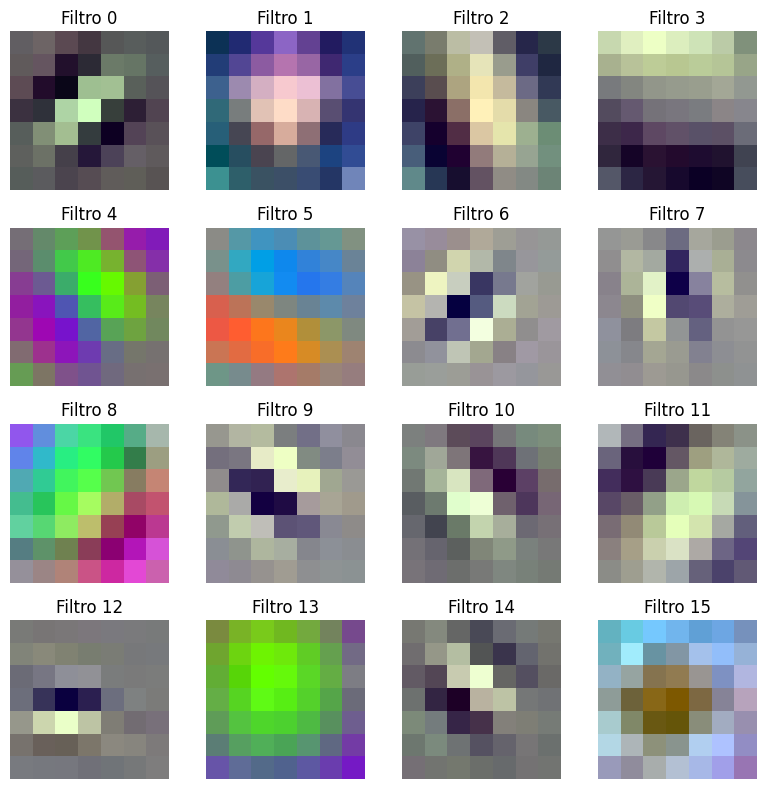

In [3]:
# TODO: visualizar filtros da primeira camada
first_conv = model.conv1.conv.weight.detach().cpu()  # GoogLeNet: conv1 e um bloco BasicConv2d
print("Shape dos filtros:", first_conv.shape)

# Dica: normalizacao por filtro para [0, 1]
def minmax_norm(x):
    x = x - x.min()
    return x / (x.max() + 1e-8)

n_show = 16
fig, axes = plt.subplots(4, 4, figsize=(8, 8))
for i, ax in enumerate(axes.flat):
    w = first_conv[i]
    w = minmax_norm(w)
    ax.imshow(np.transpose(w.numpy(), (1, 2, 0)))
    ax.set_title(f"Filtro {i}")
    ax.axis("off")
plt.tight_layout()
plt.show()

### Resposta 2.4

Quais padroes visuais aparecem com mais frequencia? Relacione com a ideia de features de baixo nivel.

In [ ]:
# Resposta 2.4 (codigo de apoio)
# Estatisticas simples para apoiar a interpretacao dos filtros.
flat = first_conv.view(first_conv.shape[0], -1)
energy = flat.pow(2).mean(dim=1)
print("Energia media dos filtros (top 8):")
print(torch.topk(energy, k=8).indices.tolist())

# Visualizacao do filtro de maior energia
idx = int(torch.argmax(energy).item())
w = first_conv[idx]
w = (w - w.min()) / (w.max() - w.min() + 1e-8)
plt.figure(figsize=(3, 3))
plt.imshow(np.transpose(w.numpy(), (1, 2, 0)))
plt.title(f"Filtro com maior energia: {idx}")
plt.axis("off")
plt.show()

## Parte 3 — Mapas de ativacao para imagens reais

Agora vamos analisar como diferentes camadas respondem a uma imagem real.

**Tarefas**
1. Registre ativacoes de pelo menos 3 camadas (inicial, intermediaria e profunda).
2. Para uma imagem de entrada, visualize alguns mapas de ativacao por camada.
3. Compare qualitativamente granularidade espacial e semantica das ativacoes.

In [4]:
# TODO: hooks para capturar ativacoes
activations = {}

def save_activation(name):
    def hook(module, inp, out):
        activations[name] = out.detach().cpu()
    return hook

hooks = []
hooks.append(model.conv1.register_forward_hook(save_activation("conv1")))
hooks.append(model.inception3a.register_forward_hook(save_activation("inception3a")))
hooks.append(model.inception5b.register_forward_hook(save_activation("inception5b")))

# TODO: escolha uma imagem e rode forward
img = sample_imgs[0]
x = preprocess(transforms.ToPILImage()(img)).unsqueeze(0).to(device)
with torch.no_grad():
    _ = model(x)

for name, feat in activations.items():
    print(name, feat.shape)

# TODO: plote mapas de ativacao (ex.: 8 canais por camada)

conv1 torch.Size([1, 64, 112, 112])
inception3a torch.Size([1, 256, 28, 28])
inception5b torch.Size([1, 1024, 7, 7])


### Resposta 3.3

Descreva as diferencas entre camadas rasas e profundas nas ativacoes observadas.

In [ ]:
# Resposta 3.3 (codigo de apoio)
# Resume ativacoes por camada para comparar granularidade e semantica.
summary = []
for name, feat in activations.items():
    summary.append({
        "camada": name,
        "shape": tuple(feat.shape),
        "media_abs": float(feat.abs().mean()),
        "std": float(feat.std()),
    })

for row in summary:
    print(row)

# Mostra 6 canais por camada (primeira imagem do batch)
for name, feat in activations.items():
    c_show = min(6, feat.shape[1])
    fig, axes = plt.subplots(1, c_show, figsize=(2 * c_show, 2))
    for i in range(c_show):
        axes[i].imshow(feat[0, i].numpy(), cmap="viridis")
        axes[i].set_title(f"{name}[{i}]")
        axes[i].axis("off")
    plt.tight_layout()
    plt.show()

## Parte 4 — Feature Visualization por otimizacao (canal)

Esta e a parte central da atividade: otimizar uma imagem para maximizar uma ativacao, como no artigo da Distill.

**Tarefas**
1. Implemente uma rotina de gradient ascent na imagem de entrada.
2. Defina um objetivo de **canal** em uma camada escolhida.
3. Gere visualizacoes para pelo menos 4 canais diferentes.
4. Salve as imagens geradas em disco.

In [5]:
# TODO: implementar feature visualization por canal
import torch.nn.functional as F

target_acts = {}
target_layer = model.inception4d
hook_target = target_layer.register_forward_hook(lambda m, i, o: target_acts.setdefault("feat", o))

def total_variation(x):
    return (x[:, :, 1:, :] - x[:, :, :-1, :]).abs().mean() + (x[:, :, :, 1:] - x[:, :, :, :-1]).abs().mean()

def optimize_channel(channel_idx, steps=200, lr=0.05, tv_weight=1e-4, l2_weight=1e-5):
    img = torch.randn(1, 3, 224, 224, device=device, requires_grad=True)
    optimizer = torch.optim.Adam([img], lr=lr)

    for _ in range(steps):
        optimizer.zero_grad()
        target_acts.clear()
        _ = model(img)
        feat = target_acts["feat"]

        obj = feat[:, channel_idx].mean()
        reg = tv_weight * total_variation(img) + l2_weight * (img ** 2).mean()
        loss = -obj + reg
        loss.backward()
        optimizer.step()

        with torch.no_grad():
            img.clamp_(0.0, 1.0)

    return img.detach().cpu().squeeze(0)

# TODO: gerar e visualizar canais [0, 1, 2, 3] ou outros

### Resposta 4.3

Compare visualmente os canais escolhidos. Eles parecem capturar estruturas diferentes?

In [ ]:
# Resposta 4.3 (codigo de apoio)
channels = [0, 1, 2, 3]
imgs = []
for c in channels:
    out = optimize_channel(c, steps=120, lr=0.04, tv_weight=1e-4, l2_weight=1e-5)
    imgs.append(out)

fig, axes = plt.subplots(1, len(channels), figsize=(3 * len(channels), 3))
for ax, c, out in zip(axes, channels, imgs):
    ax.imshow(np.transpose(out.numpy(), (1, 2, 0)))
    ax.set_title(f"Canal {c}")
    ax.axis("off")
plt.tight_layout()
plt.show()

## Parte 5 — Regularizacao e robustez da otimizacao

A Distill destaca que sem regularizacao a otimizacao tende a gerar ruido de alta frequencia.

**Tarefas**
1. Compare ao menos 3 configuracoes de regularizacao, por exemplo:
   - sem regularizacao;
   - TV + L2;
   - TV + L2 + jitter/transforms estocasticas.
2. Monte uma tabela com hiperparametros e observacoes qualitativas.
3. Indique qual configuracao produziu imagens mais interpretaveis.

In [6]:
# TODO: criar funcoes auxiliares de regularizacao e transformacao
# Sugestao: jitter espacial aleatorio a cada passo
def random_jitter(x, max_shift=8):
    dx = int(torch.randint(-max_shift, max_shift + 1, (1,)).item())
    dy = int(torch.randint(-max_shift, max_shift + 1, (1,)).item())
    return torch.roll(x, shifts=(dx, dy), dims=(2, 3))

# TODO: compare configuracoes e salve resultados
results = []
# results.append({"cfg": ..., "comentario": ...})

# Escreva seu codigo aqui

### Resposta 5.3

Explique por que regularizacao ajuda (ou nao) na interpretabilidade visual.

In [ ]:
# Resposta 5.3 (codigo de apoio)
# Compara 3 configuracoes de regularizacao para o mesmo canal.
cfgs = [
    {"nome": "sem_reg", "tv": 0.0, "l2": 0.0, "jitter": False},
    {"nome": "tv_l2", "tv": 1e-4, "l2": 1e-5, "jitter": False},
    {"nome": "tv_l2_jitter", "tv": 1e-4, "l2": 1e-5, "jitter": True},
]


def optimize_channel_cfg(channel_idx, cfg, steps=100, lr=0.04):
    img = torch.randn(1, 3, 224, 224, device=device, requires_grad=True)
    optimizer = torch.optim.Adam([img], lr=lr)

    for _ in range(steps):
        optimizer.zero_grad()
        x_in = random_jitter(img, 8) if cfg["jitter"] else img
        target_acts.clear()
        _ = model(x_in)
        feat = target_acts["feat"]

        obj = feat[:, channel_idx].mean()
        reg = cfg["tv"] * total_variation(img) + cfg["l2"] * (img ** 2).mean()
        loss = -obj + reg
        loss.backward()
        optimizer.step()
        with torch.no_grad():
            img.clamp_(0.0, 1.0)

    return img.detach().cpu().squeeze(0)

channel_idx = 10
outs = [(cfg["nome"], optimize_channel_cfg(channel_idx, cfg)) for cfg in cfgs]

fig, axes = plt.subplots(1, len(outs), figsize=(3 * len(outs), 3))
for ax, (name, out) in zip(axes, outs):
    ax.imshow(np.transpose(out.numpy(), (1, 2, 0)))
    ax.set_title(name)
    ax.axis("off")
plt.tight_layout()
plt.show()

## Parte 6 — Objetivos diferentes: canal, neuronio e classe

No guia da Distill, diferentes objetivos levam a visualizacoes diferentes.

**Tarefas**
1. Implemente ou adapte seu codigo para 3 objetivos:
   - maximizar um canal inteiro;
   - maximizar um neuronio especifico (posicao x, y, canal c);
   - maximizar logit de uma classe alvo.
2. Gere ao menos 1 exemplo por objetivo.
3. Compare qualidade visual e semantica dos resultados.

In [7]:
# TODO: objetivos de otimizacao
# Exemplo de objetivo de classe (logit pre-softmax)
def class_logit_objective(logits, class_idx):
    return logits[:, class_idx].mean()

# TODO: objetivo de neuronio e canal
# def neuron_objective(feat, c, y, x):
# def channel_objective(feat, c):

# TODO: rodar e comparar visualizacoes

### Resposta 6.3

Qual objetivo gerou visualizacoes mais uteis para interpretacao? Justifique com exemplos.

In [ ]:
# Resposta 6.3 (codigo de apoio)
def get_logits(output):
    if hasattr(output, "logits"):
        return output.logits
    if isinstance(output, tuple):
        return output[0]
    return output


def optimize_objective(objective_fn, steps=120, lr=0.04, tv_weight=1e-4, l2_weight=1e-5):
    img = torch.randn(1, 3, 224, 224, device=device, requires_grad=True)
    optimizer = torch.optim.Adam([img], lr=lr)

    for _ in range(steps):
        optimizer.zero_grad()
        target_acts.clear()
        out = model(img)
        logits = get_logits(out)
        feat = target_acts["feat"]

        obj = objective_fn(feat, logits)
        reg = tv_weight * total_variation(img) + l2_weight * (img ** 2).mean()
        loss = -obj + reg
        loss.backward()
        optimizer.step()
        with torch.no_grad():
            img.clamp_(0.0, 1.0)

    return img.detach().cpu().squeeze(0)


def obj_channel(feat, logits, c=5):
    return feat[:, c].mean()


def obj_neuron(feat, logits, c=5):
    h = feat.shape[2] // 2
    w = feat.shape[3] // 2
    return feat[:, c, h, w].mean()


def obj_class(feat, logits, class_idx=130):
    return logits[:, class_idx].mean()

samples = [
    ("canal", optimize_objective(lambda feat, logits: obj_channel(feat, logits, c=5))),
    ("neuronio", optimize_objective(lambda feat, logits: obj_neuron(feat, logits, c=5))),
    ("classe", optimize_objective(lambda feat, logits: obj_class(feat, logits, class_idx=130))),
]

fig, axes = plt.subplots(1, 3, figsize=(10, 3))
for ax, (name, out) in zip(axes, samples):
    ax.imshow(np.transpose(out.numpy(), (1, 2, 0)))
    ax.set_title(name)
    ax.axis("off")
plt.tight_layout()
plt.show()

## Parte 7 — Interacao entre features (desafio)

A Distill discute combinacoes de neuronios/direcoes no espaco de ativacoes.

**Tarefas**
1. Escolha dois canais de uma mesma camada.
2. Otimize imagens para uma combinacao linear alpha * canal_A + (1-alpha) * canal_B.
3. Varie alpha em pelo menos 5 valores (ex.: 0.0, 0.25, 0.5, 0.75, 1.0).
4. Analise se ocorre uma transicao suave entre padroes.

In [8]:
# TODO: combinacao de features
alphas = [0.0, 0.25, 0.5, 0.75, 1.0]
channel_a = 5
channel_b = 23

# Para cada alpha, otimize imagem com objetivo combinado
# obj = alpha * feat[:, channel_a].mean() + (1 - alpha) * feat[:, channel_b].mean()

# Escreva seu codigo aqui

### Resposta 7.4

A combinacao revelou algo novo sobre os canais? Discuta semelhancas e conflitos.

In [ ]:
# Resposta 7.4 (codigo de apoio)
alphas = [0.0, 0.25, 0.5, 0.75, 1.0]
channel_a = 5
channel_b = 23


def optimize_mixed(alpha, steps=100, lr=0.04):
    img = torch.randn(1, 3, 224, 224, device=device, requires_grad=True)
    optimizer = torch.optim.Adam([img], lr=lr)

    for _ in range(steps):
        optimizer.zero_grad()
        target_acts.clear()
        _ = model(img)
        feat = target_acts["feat"]

        obj = alpha * feat[:, channel_a].mean() + (1.0 - alpha) * feat[:, channel_b].mean()
        reg = 1e-4 * total_variation(img) + 1e-5 * (img ** 2).mean()
        loss = -obj + reg
        loss.backward()
        optimizer.step()
        with torch.no_grad():
            img.clamp_(0.0, 1.0)

    return img.detach().cpu().squeeze(0)

outs = [(a, optimize_mixed(a)) for a in alphas]
fig, axes = plt.subplots(1, len(outs), figsize=(3 * len(outs), 3))
for ax, (a, out) in zip(axes, outs):
    ax.imshow(np.transpose(out.numpy(), (1, 2, 0)))
    ax.set_title(f"alpha={a:.2f}")
    ax.axis("off")
plt.tight_layout()
plt.show()

## Parte 8 — Limites da tecnica e cuidados de interpretacao

**Tarefas**
1. Discuta ao menos 3 limitacoes da visualizacao por otimizacao.
2. Explique o problema de artefatos de alta frequencia.
3. Comente por que uma imagem sintetica pode ser enganosa se analisada isoladamente.
4. Sugira boas praticas para usar essa tecnica junto com outras evidencias (ex.: exemplos reais, atribuicao, metricas).

### Resposta 8

Escreva sua analise aqui.

In [ ]:
# Resposta 8 (codigo de apoio)
# Template em codigo para organizar a analise final (preencher depois).
analise = {
    "limitacoes": [
        "",
        "",
        "",
    ],
    "artefatos_alta_frequencia": "",
    "risco_de_interpretacao_isolada": "",
    "boas_praticas": [
        "",
        "",
        "",
    ],
}

for k, v in analise.items():
    print(f"{k}: {v}")

## Parte 9 — Bonus (opcional)

Escolha uma opcao:
- A) DeepDream em uma imagem real;
- B) diversidade: gerar multiplas imagens para o mesmo canal com inicializacoes diferentes;
- C) comparacao de logits versus probabilidade (softmax) como objetivo de classe.

Documente o procedimento e compare os resultados.

In [9]:
# TODO: implementacao do bonus escolhido

## Criterios de avaliacao

A correcao levara em conta:
- implementacao correta dos experimentos pedidos;
- qualidade das comparacoes entre objetivos/regularizacoes;
- clareza na interpretacao dos resultados;
- organizacao e reproducibilidade do notebook;
- coerencia entre evidencias e conclusoes.

---

## Referencia principal

Olah, C., Mordvintsev, A., Schubert, L. (2017). Feature Visualization. Distill.
https://distill.pub/2017/feature-visualization/